# Pancreatic Cancer Classification from Liquid Biopsy Gene Expression Data

This notebook presents the step-by-step solution for classifying pancreatic cancer based on gene expression data obtained from liquid biopsy samples.

**Goal:** Build a binary classifier distinguishing pancreatic cancer samples from controls (healthy + pancreatic diseases).

---

## 1. Loading the dataset

The data consists of two files:
- **counts_pancreatic.csv** - gene expression matrix (genes x samples), transposed so that rows correspond to samples and columns to genes.
- **samples_pancreatic.xlsx** - sample metadata (Group, Sex, Age, Stage, etc.).

Both files are joined on shared sample indices. The resulting `Dataset` object contains:
- `X` - DataFrame with gene expression values
- `y` - class label (Group)
- `meta` - full metadata
- `age`, `sex` - helper columns

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from utilz.Dataset import load_dataset
from utilz.constans import HEALTHY, DISEASE, CANCER

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"

ds = load_dataset(data_path, meta_path, label_col="Group")

# Preprocessing hyperparameters (used across all pipelines)
ANOVA_PERCENTILE = 60
MEAN_PERCENTILE = 20

print(f"Number of samples: {ds.X.shape[0]}")
print(f"Number of genes:   {ds.X.shape[1]}")
print(f"\nOriginal class distribution:")
print(ds.y.value_counts())

[INFO] skipped 1973 probs due to missing metadata
Number of samples: 584
Number of genes:   42630

Original class distribution:
Group
Asymptomatic controls    410
Pancreatic cancer        124
Pancreatic diseases       50
Name: count, dtype: int64


### 1.1. Metadata overview

Overview of sample metadata - demographic and clinical variables that may be potential sources of bias.

In [21]:
ds.meta.head()

,Sex,Age,Group,Institution,Lib.size,Stage,RealLocation,Mode,CA125,Platelets,Histology,Datasplit,Gdansk_sample_name,StageFull,LeukoMichal,PTPRC
AMC-HD-001-TR1139,M,23.0,Asymptomatic controls,Institute 1,1065633,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,9257.408507,167.036869
AMC-HD-002-TR1140,F,20.0,Asymptomatic controls,Institute 1,1126605,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,7145.361506,47.043995
AMC-HD-003-TR1141,F,21.0,Asymptomatic controls,Institute 1,698667,NaN,AMC,Single,NaN,NaN,NaN,Validation,NaN,n.a.,10362.590476,88.740416
AMC-HD-004-TR1142,F,21.0,Asymptomatic controls,Institute 1,850492,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,5721.394205,23.515800
AMC-HD-005-TR1143,F,21.0,Asymptomatic controls,Institute 1,824835,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,14561.700219,58.193457


In [22]:
print(f"Columns: {list(ds.meta.columns)}")
print(f"Sex:     {ds.sex.value_counts().to_dict()}")
print(f"Age:     min={ds.age.min():.0f}, max={ds.age.max():.0f}, "
      f"median={ds.age.median():.0f}, mean={ds.age.mean():.1f}")
if 'Stage' in ds.meta.columns:
    print(f"Stage:   {ds.meta['Stage'].value_counts().to_dict()}")

Columns: ['Sex', 'Age', 'Group', 'Institution', 'Lib.size', 'Stage', 'RealLocation', 'Mode', 'CA125', 'Platelets', 'Histology', 'Datasplit', 'Gdansk_sample_name', 'StageFull', 'LeukoMichal', 'PTPRC']
Sex:     {'F': 316, 'M': 253, 'n.a.': 15}
Age:     min=18, max=87, median=56, mean=54.1
Stage:   {'II': 64, 'III': 31, 'IV': 26, 'I': 3}


### 1.2. Expression matrix - basic statistics

In [23]:
expr_stats = {
    "Shape (samples x genes)": f"{ds.X.shape[0]} x {ds.X.shape[1]}",
    "Value range": f"[{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]",
    "Missing values": ds.X.isna().sum().sum(),
}
for k, v in expr_stats.items():
    print(f"{k}: {v}")

ds.X.T.head(10).describe()

Shape (samples x genes): 584 x 42630
Value range: [2.28, 17.51]
Missing values: 0


,AMC-HD-001-TR1139,AMC-HD-002-TR1140,AMC-HD-003-TR1141,AMC-HD-004-TR1142,AMC-HD-005-TR1143,AMC-HD-006-TR1144,AMC-HD-007-TR1145,AMC-HD-008-TR1146,AMC-HD-010-TR1147,AS1_TEPs,...,Vumc-chPan-117-2015563-TR1945,Vumc-chPan-37-20161051-TR2688,Vumc-chPan-38-2016720-TR2689,Vumc-chPan-84-2016313-TR2652,Vumc-chPan93-201611735-TR2653,Vumc-exIPMN-3-TR1042,Vumc-exIPMN-56-TR1043,Vumc-exIPMN-58-2016494-TR2629,Vumc-exIPMN-84-2015196-TR1926,Vumc-xIPMN111-20161026-TR2631
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,...,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,3.687300,3.042400,3.079900,2.898200,2.956800,2.914000,3.236400,2.839800,2.974200,3.81440,...,3.38850,2.913700,3.201400,2.884000,3.937400,3.410900,3.299900,3.52470,3.253900,2.595100
std,1.428765,1.063724,1.131887,0.754569,0.979377,0.882516,0.889681,0.793003,0.925745,1.51710,...,1.23936,1.121087,1.352924,0.728203,1.472593,1.549943,1.046055,1.55377,1.114889,0.720574
min,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.27800,...,2.27800,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.27800,2.278000,2.278000
25%,2.480000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.278000,2.87350,...,2.27800,2.278000,2.278000,2.278000,2.626250,2.278000,2.278000,2.27800,2.278000,2.278000
50%,3.086000,2.278000,2.278000,2.555500,2.278000,2.278000,3.469000,2.278000,2.278000,3.29700,...,3.07700,2.278000,2.278000,2.594500,3.769500,2.278000,3.230500,3.14200,3.022500,2.278000
75%,4.840750,3.783500,4.157750,3.463000,3.611000,3.547750,3.869500,3.214000,3.843000,4.49975,...,4.19300,3.033250,3.985000,3.310250,4.792250,4.674250,3.893250,4.31225,3.896000,2.278000
max,5.869000,5.190000,4.943000,4.155000,4.880000,4.526000,4.666000,4.305000,4.584000,7.29100,...,5.39400,5.070000,6.165000,4.240000,6.850000,5.886000,4.910000,6.89900,5.381000,4.434000


---

## 2. Label preparation - binary classification

The dataset contains three original classes:
- **Asymptomatic controls** - healthy individuals
- **Pancreatic diseases** - other pancreatic conditions
- **Pancreatic cancer** - pancreatic cancer

The goal is to detect pancreatic cancer, so we merge *Asymptomatic controls* and *Pancreatic diseases* into a single control class. The problem becomes binary classification:

| New label | Original classes |
|---|---|
| 0 - Control | Asymptomatic controls + Pancreatic diseases |
| 1 - Cancer | Pancreatic cancer |

In [24]:
# Merge classes: Pancreatic diseases -> Asymptomatic controls
ds.y = ds.y.replace({DISEASE: HEALTHY})

print("Class distribution after merging:")
print(ds.y.value_counts())
print(f"\nClass ratio (control/cancer): {(ds.y == HEALTHY).sum() / (ds.y == CANCER).sum():.2f}")

Class distribution after merging:
Group
Asymptomatic controls    460
Pancreatic cancer        124
Name: count, dtype: int64

Class ratio (control/cancer): 3.71


In [25]:
# Encode labels numerically
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)

print("Class mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {code} -> {cls}")

print(f"\nEncoded label distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
  0 -> Asymptomatic controls
  1 -> Pancreatic cancer

Encoded label distribution:
0    460
1    124
Name: count, dtype: int64


---

## 3. Train / Test / Validation split

The data is split as follows:
- **50%** - training set
- **25%** - validation set (used for decision threshold tuning)
- **25%** - test set (used for final model evaluation)

### Stratification

To avoid bias in the split, we apply combined stratification across four variables:
1. **Class** (y) - cancer vs. control
2. **Sex**
3. **Age group** (Age quantiled into 3 bins: young/mid/old)
4. **Stage** (grouped as I_II / III / IV / none)

This ensures that each subset maintains similar proportions of these variables, minimizing the risk of confounding.

In [26]:
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=0.15, valid_size=0.15)
)

print(f"Split sizes:")
print(f"  Train:      {X_train.shape[0]} samples ({X_train.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Validation: {X_valid.shape[0]} samples ({X_valid.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]} samples ({X_test.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Total:      {X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]} samples")
print(f"\nNumber of features: {X_train.shape[1]}")

[INFO] 8 samples with unique strata added to train set
[INFO] 6 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Split sizes:
  Train:      417 samples (71.4%)
  Validation: 84 samples (14.4%)
  Test:       83 samples (14.2%)
  Total:      584 samples

Number of features: 42630


### 3.1. Split balance overview

Class counts, proportions, and demographic distributions across train/test/validation splits.

In [27]:
split_summary = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Validation': y_valid.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
})
split_summary.index = [le.inverse_transform([i])[0] for i in split_summary.index]
split_summary.loc['Total'] = split_summary.sum()
display(split_summary)

# Class proportions per split
split_pct = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).sort_index() * 100,
    'Validation (%)': y_valid.value_counts(normalize=True).sort_index() * 100,
    'Test (%)': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_pct.index = [le.inverse_transform([i])[0] for i in split_pct.index]
display(split_pct.round(1))

from utilz.helpers import plot_split_balance

plot_split_balance({
    'Train': (y_train, ds.sex.loc[X_train.index], ds.age.loc[X_train.index]),
    'Test':  (y_test,  ds.sex.loc[X_test.index],  ds.age.loc[X_test.index]),
    'Valid': (y_valid, ds.sex.loc[X_valid.index], ds.age.loc[X_valid.index]),
})

,Train,Validation,Test
Asymptomatic controls,324,70,66
Pancreatic cancer,93,14,17
Total,417,84,83


,Train (%),Validation (%),Test (%)
Asymptomatic controls,77.7,83.3,79.5
Pancreatic cancer,22.3,16.7,20.5


### 3.2. Disease stage distribution across splits

In [28]:
# Group Stage I and II together (only 3 Stage I samples)
stage_col = ds.meta['Stage'].copy()
stage_col = stage_col.replace({'I': 'I-II', 'II': 'I-II'})

stage_summary = pd.DataFrame({
    'Train': stage_col.loc[X_train.index].value_counts(),
    'Validation': stage_col.loc[X_valid.index].value_counts(),
    'Test': stage_col.loc[X_test.index].value_counts(),
}).fillna(0).astype(int)

print("Disease stage distribution across splits (Stage I+II merged):")
stage_summary

Disease stage distribution across splits (Stage I+II merged):


,Train,Validation,Test
Stage,,,
I-II,47,10,10
III,25,2,4
IV,21,2,3


### 3.3. Data leakage check

Verify that no sample appears in more than one split.

In [29]:
train_test_overlap = X_train.index.intersection(X_test.index)
train_valid_overlap = X_train.index.intersection(X_valid.index)
test_valid_overlap = X_test.index.intersection(X_valid.index)

print(f"Overlap Train - Test:       {len(train_test_overlap)}")
print(f"Overlap Train - Validation: {len(train_valid_overlap)}")
print(f"Overlap Test  - Validation: {len(test_valid_overlap)}")

assert len(train_test_overlap) + len(train_valid_overlap) + len(test_valid_overlap) == 0, \
    "Data leakage detected!"
print("\nNo data leakage - all splits are disjoint.")

Overlap Train - Test:       0
Overlap Train - Validation: 0
Overlap Test  - Validation: 0

No data leakage - all splits are disjoint.


---

## 4. Preprocessing - feature reduction pipeline

The preprocessing pipeline reduces 42,630 genes to a manageable set by sequentially applying:

| Step | Reducer | Purpose |
|---|---|---|
| 1 | **ConstantExpressionReductor** | Remove genes with zero variance (single unique value) |
| 2 | **AnovaReductor** (percentile=70) | Keep top 30% genes by ANOVA F-score vs. class label |
| 3 | **MeanExpressionReductor** (percentile=10) | Remove bottom 10% by mean expression level |
| 4 | **AgeBiasReductor** | Remove genes significantly correlated with age (OLS + FDR-BH) |
| 5 | **SexBiasReductor** | Remove genes significantly correlated with sex (OLS + FDR-BH) |
| 6 | **StandardScaler** | Zero-mean, unit-variance normalization |

All reductors are **fit on the training set only** and applied to validation/test sets to prevent data leakage.

### 4.1. Pipeline definition and gene reduction summary

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
)

sex_numeric = ds.sex.map({"F": 0, "M": 1})

pipeline = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor',  CovariatesBiasReductor(covariate=ds.age)),
    ('SexBiasReductor',  CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
])

# Fit & transform step by step to track gene counts
step_names = []
step_counts = []
step_genes = {}

X_current = X_train.copy()
step_names.append("Raw input")
step_counts.append(X_current.shape[1])
step_genes["Raw input"] = list(X_current.columns)

for name, transformer in pipeline.steps:
    if name == 'scaler':
        transformer.fit(X_current)
        X_current = pd.DataFrame(
            transformer.transform(X_current),
            columns=X_current.columns, index=X_current.index
        )
    else:
        transformer.fit(X_current, y_train)
        X_current = transformer.transform(X_current)
    step_names.append(name)
    step_counts.append(X_current.shape[1])
    if name != 'scaler':
        step_genes[name] = list(transformer.selected_genes_)

# Summary table
reduction_df = pd.DataFrame({
    'Step': step_names,
    'Genes remaining': step_counts,
    'Genes removed': [0] + [step_counts[i] - step_counts[i+1] for i in range(len(step_counts)-1)],
})
reduction_df['% of original'] = (reduction_df['Genes remaining'] / step_counts[0] * 100).round(1)

print(f"Preprocessing pipeline: {step_counts[0]} → {step_counts[-1]} genes\n")
reduction_df

data shape after ConstantExpressionReductor:  (417, 31716)
data shape after AnovaReductor:  (417, 12686)
data shape after MeanExpressionReductor:  (417, 10148)
-0.002402963626791504
0.0037759914298015683
-0.022383401627335327 0.022140167002244176
data shape after CovariatesBiasReductor:  (417, 9727)
-0.07034715604546489
0.12175631228326074
-0.6722971905918737 3.5209286342741835
data shape after CovariatesBiasReductor:  (417, 9680)
Preprocessing pipeline: 42630 → 9680 genes



,Step,Genes remaining,Genes removed,% of original
0,Raw input,42630,0,100.0
1,ConstantExpressionReductor,31716,10914,74.4
2,AnovaReductor,12686,19030,29.8
3,MeanExpressionReductor,10148,2538,23.8
4,AgeBiasReductor,9727,421,22.8
5,SexBiasReductor,9680,47,22.7
6,scaler,9680,0,22.7


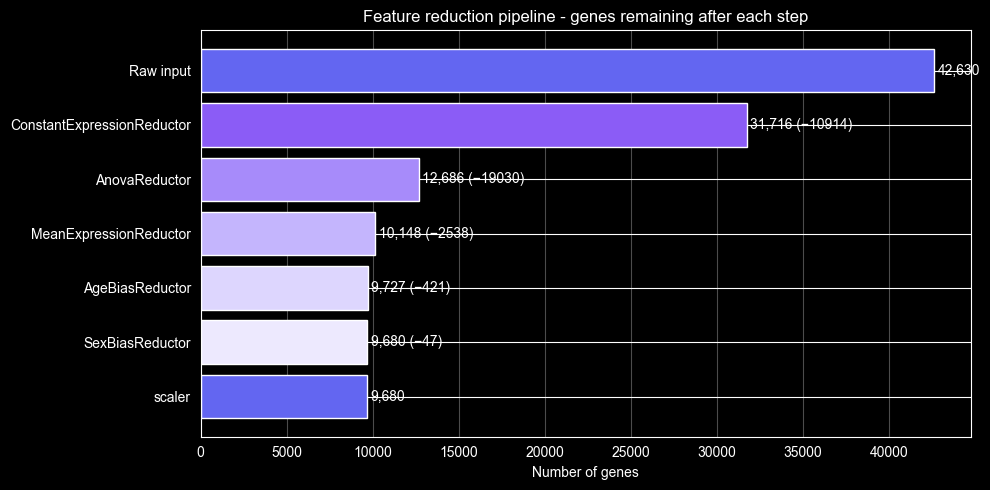

In [31]:
# Visualize gene reduction funnel
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe']
bars = ax.barh(range(len(step_names)), step_counts, color=colors[:len(step_names)])

for i, (count, name) in enumerate(zip(step_counts, step_names)):
    removed = f" (−{step_counts[i-1] - count})" if i > 0 and step_counts[i-1] != count else ""
    ax.text(count + 200, i, f"{count:,}{removed}", va='center', fontsize=10)

ax.set_yticks(range(len(step_names)))
ax.set_yticklabels(step_names)
ax.invert_yaxis()
ax.set_xlabel("Number of genes")
ax.set_title("Feature reduction pipeline - genes remaining after each step")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2. PCA before and after preprocessing

PCA visualization on the **test set** shows how the preprocessing pipeline improves class separability. Before preprocessing, the 42k-dimensional space contains noise from constant, low-variance, and confounded genes. After filtering, the principal components capture more disease-relevant variation.

=== PCA BEFORE preprocessing ===


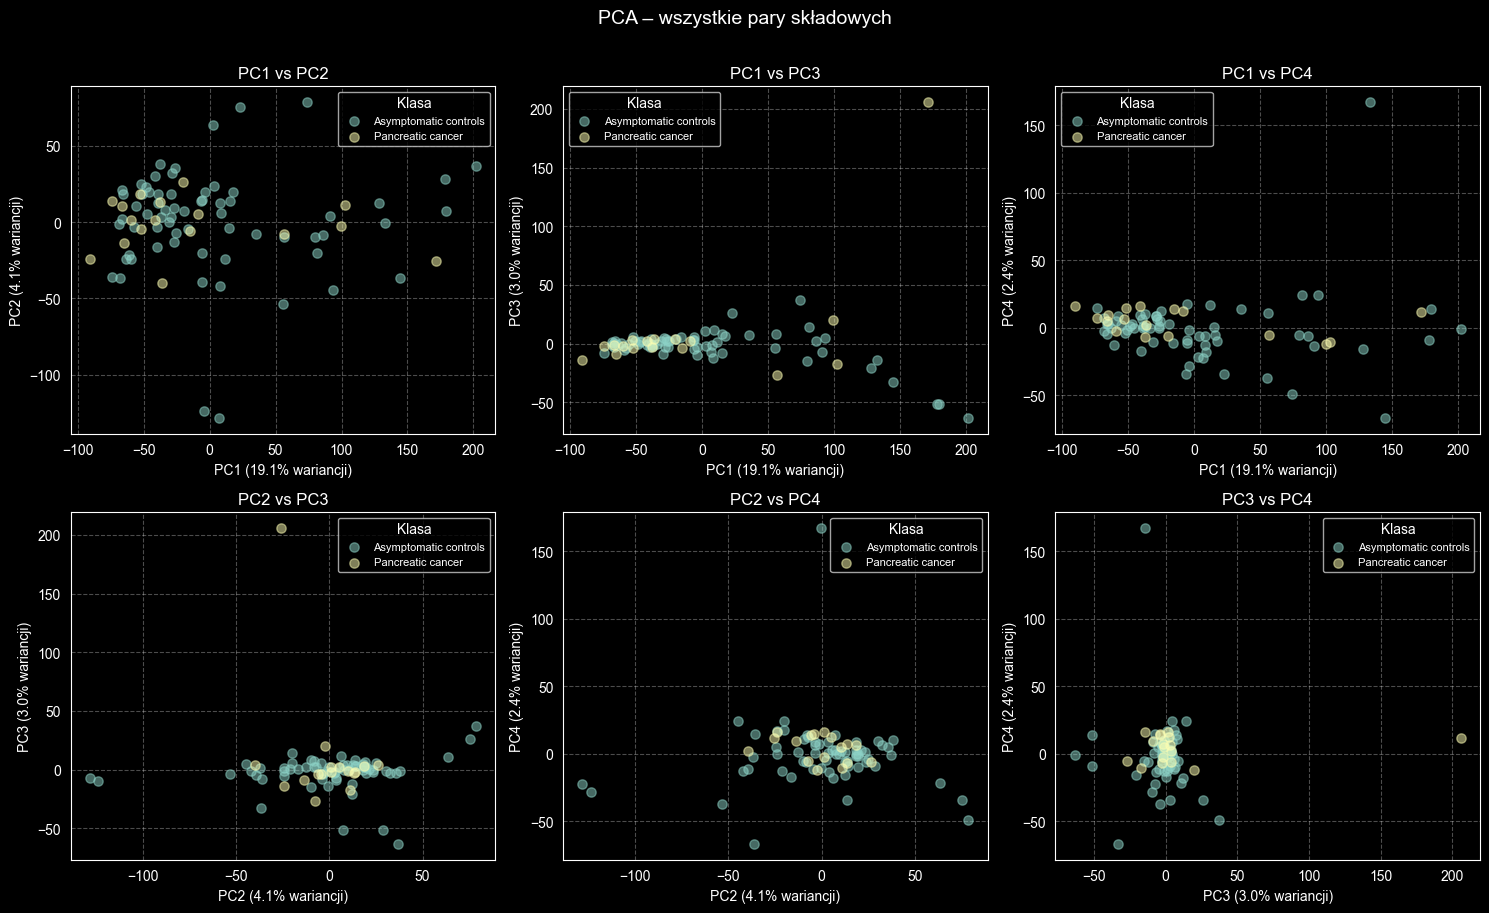

data shape after ConstantExpressionReductor:  (83, 31716)
data shape after AnovaReductor:  (83, 12686)
data shape after MeanExpressionReductor:  (83, 10148)
data shape after CovariatesBiasReductor:  (83, 9727)
data shape after CovariatesBiasReductor:  (83, 9680)

=== PCA AFTER preprocessing (9680 genes) ===


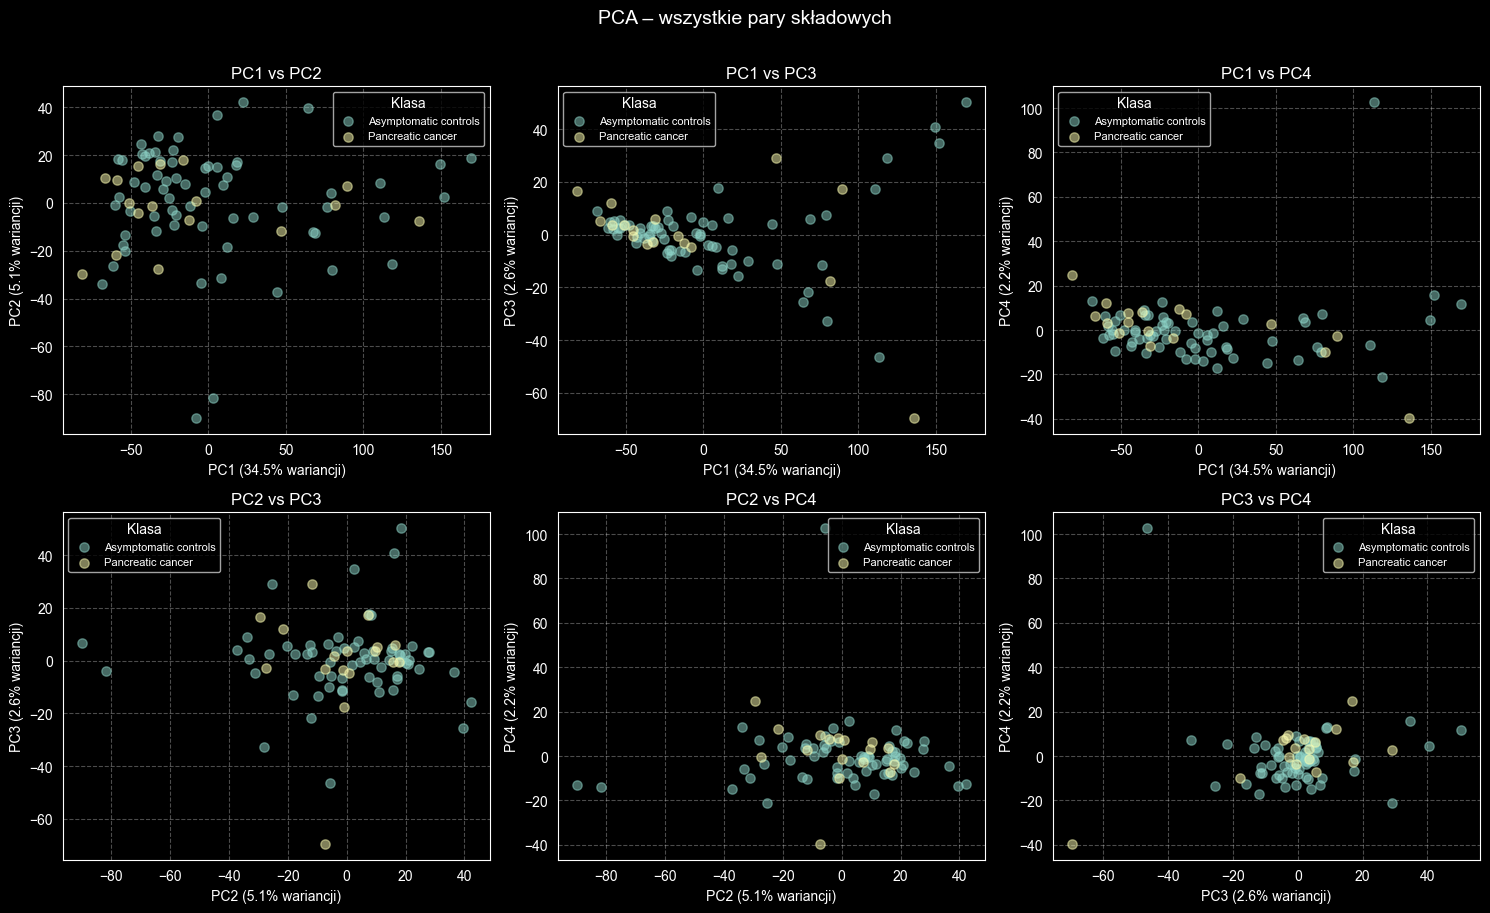

In [32]:
from utilz.helpers import plot_pca

num_pca_components = 4

print("=== PCA BEFORE preprocessing ===")
plot_pca(X_test, y_test, num_pca_components, le)

# Apply the fitted pipeline (without scaler) to test set for PCA
X_test_filtered = X_test.copy()
for name, transformer in pipeline.steps:
    if name == 'scaler':
        break
    X_test_filtered = transformer.transform(X_test_filtered)

print(f"\n=== PCA AFTER preprocessing ({X_test_filtered.shape[1]} genes) ===")
plot_pca(X_test_filtered, y_test, num_pca_components, le)

### 4.3. ANOVA filtering effect

The AnovaReductor keeps the top genes by ANOVA F-score (between-class variance). Below we compare this with overall gene variance to show which genes are retained.

data shape after ConstantExpressionReductor:  (417, 31716)


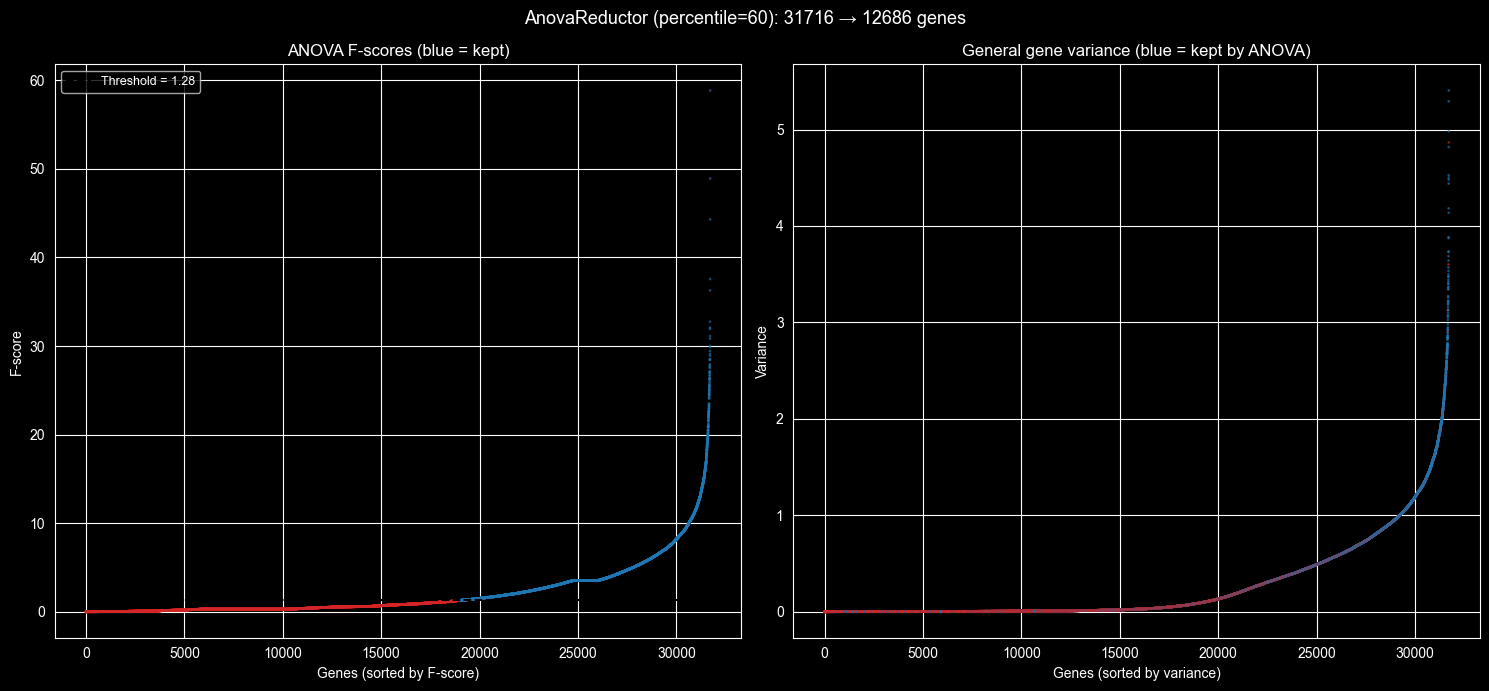

In [33]:
from sklearn.feature_selection import f_classif

# Get data after ConstantExpressionReductor
const_reductor = pipeline.named_steps['ConstantExpressionReductor']
X_after_const = const_reductor.transform(X_train)

# ANOVA F-scores (between-class variance)
f_scores, p_values = f_classif(X_after_const, y_train)

# Overall variance per gene
gene_variance = X_after_const.var(axis=0).values

# ANOVA threshold
threshold = np.percentile(f_scores, ANOVA_PERCENTILE)
kept_mask = f_scores > threshold

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Sorted F-scores with threshold
sorted_f_idx = np.argsort(f_scores)
sorted_f = f_scores[sorted_f_idx]
colors_f = ['tab:blue' if f > threshold else 'tab:red' for f in sorted_f]
axes[0].scatter(range(len(sorted_f)), sorted_f, c=colors_f, s=1, alpha=0.5)
axes[0].axhline(threshold, color='black', ls='--', lw=1.5, label=f'Threshold = {threshold:.2f}')
axes[0].set(xlabel='Genes (sorted by F-score)', ylabel='F-score',
            title='ANOVA F-scores (blue = kept)')
axes[0].legend(fontsize=9)

# Genes sorted by overall variance, colored by ANOVA decision
sorted_var_idx = np.argsort(gene_variance)
sorted_var = gene_variance[sorted_var_idx]
sorted_kept = kept_mask[sorted_var_idx]
colors_var = ['tab:blue' if k else 'tab:red' for k in sorted_kept]
axes[1].scatter(range(len(sorted_var)), sorted_var, c=colors_var, s=1, alpha=0.5)
axes[1].set(xlabel='Genes (sorted by variance)', ylabel='Variance',
            title='General gene variance (blue = kept by ANOVA)')

plt.suptitle(f'AnovaReductor (percentile={ANOVA_PERCENTILE}): {len(f_scores)} → {kept_mask.sum()} genes', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4. Age bias removal - validation

To verify that the AgeBiasReductor effectively removes age-correlated signal, we train a simple age prediction model (Lasso regression) on healthy controls before and after debiasing. A successful reductor should **decrease** the model's ability to predict age from gene expression, confirming that confounding age signal has been removed.

data shape after ConstantExpressionReductor:  (402, 31434)
data shape after AnovaReductor:  (402, 12574)
data shape after MeanExpressionReductor:  (402, 10059)
data shape after ConstantExpressionReductor:  (80, 31434)
data shape after AnovaReductor:  (80, 12574)
data shape after MeanExpressionReductor:  (80, 10059)
data shape after ConstantExpressionReductor:  (80, 31434)
data shape after AnovaReductor:  (80, 12574)
data shape after MeanExpressionReductor:  (80, 10059)
data shape after ConstantExpressionReductor:  (80, 31434)
data shape after AnovaReductor:  (80, 12574)
data shape after MeanExpressionReductor:  (80, 10059)
data shape after ConstantExpressionReductor:  (402, 31434)
data shape after AnovaReductor:  (402, 12574)
data shape after MeanExpressionReductor:  (402, 10059)
-0.0014358051804852715
0.0023018820011709395
-0.013137706756135325 0.0160690403960418
data shape after CovariatesBiasReductor:  (402, 7396)
data shape after ConstantExpressionReductor:  (80, 31434)
data shape 

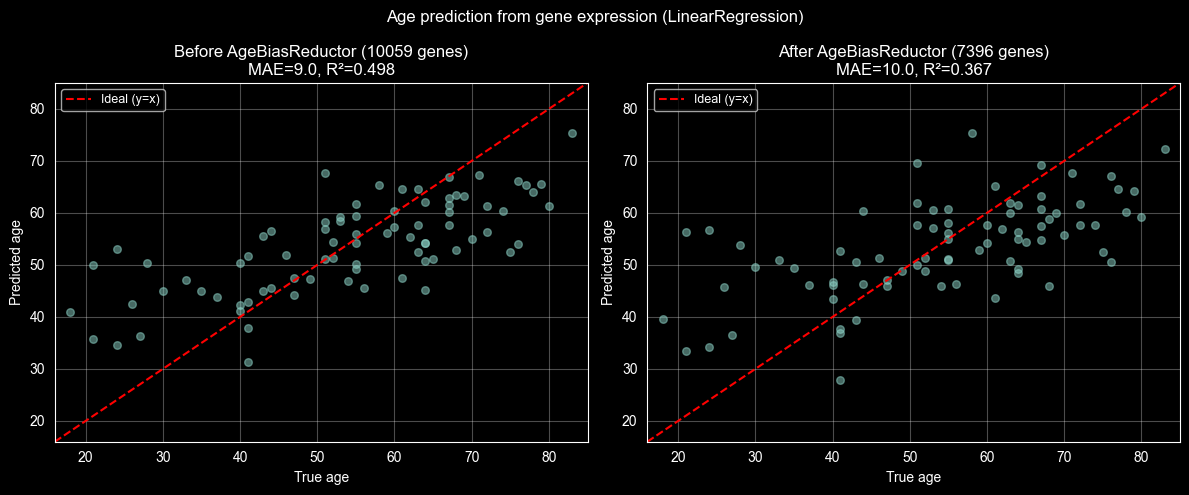

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Two pipelines: with and without AgeBiasReductor
pipe_without_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

pipe_with_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor', CovariatesBiasReductor(covariate=ds.age)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

age = ds.age.dropna().astype(int)
tr_idx = X_train.index.intersection(age.index)
te_idx = X_test.index.intersection(age.index)

# --- Before AgeBiasReductor ---
pipe_without_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_before = pipe_without_age.predict(X_test.loc[te_idx])
n_before = pipe_without_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_before = mean_absolute_error(age.loc[te_idx], pred_before)
r2_before = pipe_without_age.score(X_test.loc[te_idx], age.loc[te_idx])

# --- After AgeBiasReductor ---
pipe_with_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_after = pipe_with_age.predict(X_test.loc[te_idx])
n_after = pipe_with_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_after = mean_absolute_error(age.loc[te_idx], pred_after)
r2_after = pipe_with_age.score(X_test.loc[te_idx], age.loc[te_idx])

print(f"Before AgeBiasReductor ({n_before} genes): MAE={mae_before:.2f} years, R²={r2_before:.4f}")
print(f"After AgeBiasReductor  ({n_after} genes):  MAE={mae_after:.2f} years, R²={r2_after:.4f}")

# Plot
y_true = age.loc[te_idx]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, n, mae, r2, title in [
    (ax1, pred_before, n_before, mae_before, r2_before, "Before AgeBiasReductor"),
    (ax2, pred_after, n_after, mae_after, r2_after, "After AgeBiasReductor"),
]:
    lim = [min(y_true.min(), pred.min()) - 2, max(y_true.max(), pred.max()) + 2]
    ax.scatter(y_true, pred, alpha=0.5, s=30)
    ax.plot(lim, lim, 'r--', label='Ideal (y=x)')
    ax.set(xlim=lim, ylim=lim, xlabel="True age", ylabel="Predicted age",
           title=f"{title} ({n} genes)\nMAE={mae:.1f}, R²={r2:.3f}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Age prediction from gene expression (LinearRegression)", fontsize=12)
plt.tight_layout()
plt.show()

### 4.5. Sex bias removal - validation

Analogous test for SexBiasReductor: we train a sex classifier (Logistic Regression) on healthy controls before and after removing sex-correlated genes. A successful reductor should decrease sex classification accuracy.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score

# Two pipelines: with and without SexBiasReductor
pipe_without_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor', CovariatesBiasReductor(covariate=ds.age)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500)),
])

pipe_with_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor', CovariatesBiasReductor(covariate=ds.age)),
    ('SexBiasReductor', CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500)),
])

sex = sex_numeric.dropna().astype(int)
tr_idx_s = X_train.index.intersection(sex.index)
te_idx_s = X_test.index.intersection(sex.index)

# --- Before SexBiasReductor ---
pipe_without_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_before_sex = pipe_without_sex.predict(X_test.loc[te_idx_s])
n_before_sex = pipe_without_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_before = balanced_accuracy_score(sex.loc[te_idx_s], pred_before_sex)
f1_before = f1_score(sex.loc[te_idx_s], pred_before_sex, average='weighted')

# --- After SexBiasReductor ---
pipe_with_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_after_sex = pipe_with_sex.predict(X_test.loc[te_idx_s])
n_after_sex = pipe_with_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_after = balanced_accuracy_score(sex.loc[te_idx_s], pred_after_sex)
f1_after = f1_score(sex.loc[te_idx_s], pred_after_sex, average='weighted')

print("Sex classification (test set):")
print("-" * 55)
print(f"Before SexBiasReductor ({n_before_sex} genes):")
print(f"  Balanced Accuracy: {ba_before:.3f},  F1: {f1_before:.3f}")
print(f"After SexBiasReductor  ({n_after_sex} genes):")
print(f"  Balanced Accuracy: {ba_after:.3f},  F1: {f1_after:.3f}")

data shape after ConstantExpressionReductor:  (406, 31627)
data shape after AnovaReductor:  (406, 12636)
data shape after MeanExpressionReductor:  (406, 10108)
-0.0028736237109103545
0.004272853523078277
-0.026603759451698548 0.024289476593786042
data shape after CovariatesBiasReductor:  (406, 8352)
data shape after ConstantExpressionReductor:  (81, 31627)
data shape after AnovaReductor:  (81, 12636)
data shape after MeanExpressionReductor:  (81, 10108)
data shape after CovariatesBiasReductor:  (81, 8352)
data shape after ConstantExpressionReductor:  (81, 31627)
data shape after AnovaReductor:  (81, 12636)
data shape after MeanExpressionReductor:  (81, 10108)
data shape after CovariatesBiasReductor:  (81, 8352)
data shape after ConstantExpressionReductor:  (406, 31627)
data shape after AnovaReductor:  (406, 12636)
data shape after MeanExpressionReductor:  (406, 10108)
-0.0028736237109103545
0.004272853523078277
-0.026603759451698548 0.024289476593786042
data shape after CovariatesBiasR

### 4.6. Final preprocessed datasets

Apply the full pipeline to produce train/validation/test sets ready for model training.

In [36]:
X_train = pipeline.fit_transform(X_train, y_train)
X_valid = pipeline.transform(X_valid)
X_test = pipeline.transform(X_test)

data shape after ConstantExpressionReductor:  (417, 31716)
data shape after AnovaReductor:  (417, 12686)
data shape after MeanExpressionReductor:  (417, 10148)
-0.002402963626791504
0.0037759914298015683
-0.022383401627335327 0.022140167002244176
data shape after CovariatesBiasReductor:  (417, 9727)
-0.07034715604546489
0.12175631228326074
-0.6722971905918737 3.5209286342741835
data shape after CovariatesBiasReductor:  (417, 9680)
data shape after ConstantExpressionReductor:  (84, 31716)
data shape after AnovaReductor:  (84, 12686)
data shape after MeanExpressionReductor:  (84, 10148)
data shape after CovariatesBiasReductor:  (84, 9727)
data shape after CovariatesBiasReductor:  (84, 9680)
data shape after ConstantExpressionReductor:  (83, 31716)
data shape after AnovaReductor:  (83, 12686)
data shape after MeanExpressionReductor:  (83, 10148)
data shape after CovariatesBiasReductor:  (83, 9727)
data shape after CovariatesBiasReductor:  (83, 9680)


---

## 5. Ensemble model with calibration

We combine three classifiers — Logistic Regression, SVM (RBF), and XGBoost — using a StackingClassifier, then apply Beta Calibration to improve probability estimates.

| Component | Method | Description |
|---|---|---|
| **StackingClassifier** | Stacking | Meta-learner (LogReg) trained on base model predictions |
| **Beta Calibration** | Post-hoc calibration | Fits a Beta distribution to align predicted probabilities with true frequencies |

All base models use hyperparameters from grid search. Decision threshold is tuned on the validation set (Youden's J statistic).

### 5.1. Base model definitions

Individual classifiers with tuned hyperparameters from grid search.

In [37]:
from collections import Counter
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                             balanced_accuracy_score, classification_report, confusion_matrix)

class_counts = Counter(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True
)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=300,
    colsample_bytree=0.6, gamma=0.14, learning_rate=0.12,
    max_depth=5, min_child_weight=3, reg_alpha=0.75,
    reg_lambda=0.78, subsample=0.79, random_state=2137
)

print(f"Class ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Base models: LogisticRegression, RF, XGBClassifier")

Class ratio (neg/pos): 3.48
Base models: LogisticRegression, RF, XGBClassifier


### 5.2. StackingClassifier

Stacking with a LogisticRegression meta-learner trained on base model predictions (predict_proba).

In [38]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

stacking = StackingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb), ('rf', rf)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False
)

stacking.fit(X_train, y_train)

# Raw probabilities
scores_valid_raw = stacking.predict_proba(X_valid)[:, 1]
scores_test_raw = stacking.predict_proba(X_test)[:, 1]

# Threshold tuning on validation set (Youden's J)
fpr_v, tpr_v, thresholds_v = roc_curve(y_valid, scores_valid_raw)
raw_threshold = thresholds_v[np.argmax(tpr_v - fpr_v)]

y_pred_raw = (scores_test_raw >= raw_threshold).astype(int)

print("=== Before calibration ===")
print(f"Optimal threshold: {raw_threshold:.4f}")
print(f"AUC:               {roc_auc_score(y_test, scores_test_raw):.4f}")
print(f"F1 (weighted):     {f1_score(y_test, y_pred_raw, average='weighted'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_raw):.4f}")
print(f"\n{classification_report(y_test, y_pred_raw, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_raw)}")


=== Before calibration ===
Optimal threshold: 0.1461
AUC:               0.8717
F1 (weighted):     0.8043
Balanced accuracy: 0.7402

                       precision    recall  f1-score   support

Asymptomatic controls       0.90      0.83      0.87        66
    Pancreatic cancer       0.50      0.65      0.56        17

             accuracy                           0.80        83
            macro avg       0.70      0.74      0.72        83
         weighted avg       0.82      0.80      0.80        83



### 5.3. Beta Calibration

Beta Calibration fits a Beta distribution to the raw predicted probabilities using the validation set. This corrects overconfident or underconfident predictions, improving the reliability of probability estimates.

In [42]:
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as LR
from netcal.scaling import BetaCalibration, TemperatureScaling

results = {}

# Beta (już masz)
cal_beta = BetaCalibration(detection=False)
cal_beta.fit(scores_valid_raw, y_valid.values)
results['Beta'] = cal_beta.transform(scores_test_raw)

# Platt (sigmoid)
cal_platt = LR(max_iter=1000)
cal_platt.fit(scores_valid_raw.reshape(-1, 1), y_valid)
results['Platt'] = cal_platt.predict_proba(scores_test_raw.reshape(-1, 1))[:, 1]

# Isotonic — elastyczna, może overfitować przy <1000 próbek [web:31]
cal_iso = IsotonicRegression(out_of_bounds='clip')
cal_iso.fit(scores_valid_raw, y_valid)
results['Isotonic'] = cal_iso.predict(scores_test_raw)

# Temperature Scaling — 1 parametr, najmniej overfituje
cal_temp = TemperatureScaling()
cal_temp.fit(scores_valid_raw, y_valid.values)
results['Temperature'] = cal_temp.transform(scores_test_raw)

for name, p_cal in results.items():
    fpr_c, tpr_c, thr_c = roc_curve(y_valid,
        cal_beta.transform(scores_valid_raw) if name=='Beta' else p_cal)
    # użyj valid do threshold
    print(f"{name:12s} | AUC: {roc_auc_score(y_test, p_cal):.4f} "
          f"| Brier: {brier_score_loss(y_test, p_cal):.4f} "
          f"| LogLoss: {log_loss(y_test, p_cal):.4f}")

AttributeError: `np.infty` was removed in the NumPy 2.0 release. Use `np.inf` instead.

### 5.4. Calibration comparison

Reliability diagram and probability distribution before vs. after Beta Calibration.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Reliability diagram
for probs, label, color in [
    (scores_test_raw, "Raw stacking", "steelblue"),
    (p_calibrated, "Beta Calibration", "darkorange"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[0].plot(mean_pred, frac_pos, marker='o', label=label, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label="Perfect")
axes[0].set(title="Reliability diagram", xlabel="Predicted probability",
            ylabel="True fraction of positives")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 2. Probability distribution
axes[1].hist(scores_test_raw, bins=20, alpha=0.5, label="Raw stacking", color="steelblue")
axes[1].hist(p_calibrated, bins=20, alpha=0.5, label="Beta Calibration", color="darkorange")
axes[1].set(title="Probability distribution", xlabel="p(cancer)", ylabel="Count")
axes[1].legend(fontsize=9)

# 3. ROC curve comparison
for probs, preds, label, color in [
    (scores_test_raw, y_pred_raw, "Raw stacking", "steelblue"),
    (p_calibrated, y_pred_cal, "Beta Calibration", "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ba = balanced_accuracy_score(y_test, preds)
    axes[2].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f}, BA={ba:.3f})', color=color)

axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set(title="ROC curves", xlabel="FPR", ylabel="TPR")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle("Stacking ensemble: before vs. after Beta Calibration (test set)", fontsize=13)
plt.tight_layout()
plt.show()